# Retirement Tax Optimizer — Spouse A & Spouse B (package edition)

**Goal:** maximize after-tax terminal net worth at the planning horizon, subject to never running out of money, by jointly choosing:

1. **Pre-retirement** allocation between Traditional 401(k) and Roth 401(k) for each spouse.
2. **In-retirement** withdrawal sequencing across taxable / pretax / Roth buckets.
3. **Roth-conversion** size during the retirement-to-RMD gap years.

All simulation logic lives in the `tax_optimizer/` Python package. This notebook is a thin orchestration layer that:

- Imports the engine and configures a scenario.
- Runs the four-strategy comparison + tornado sensitivity (deterministic).
- Demonstrates the v2 capabilities:
  - **Monte Carlo** sequence-of-returns risk (`§8`).
  - **Widow's-penalty / single-filer mortality** stress test (`§9`).
  - **Tax-regime change** (TCJA sunset) stress test (`§10`).
  - **Smile-shaped retirement spending** + lump events (`§11`).
  - **Asset location** (per-account equity / bond mix) (`§12`).

To use your own scenario, edit cell `§1` and re-run.


## §1. Scenario inputs

In [49]:
from __future__ import annotations
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tax_optimizer import (
    Config,
    Inputs,
    StartingBalances,
    CurrentIncome,
    CurrentContrib,
    PensionInputs,
    SocialSecurity,
    SpendingProfile,
    SpendingPhase,
    LumpEvent,
    LongTermCareShock,
    AssetLocation,
    AssetMix,
    DeterministicModel,
    LognormalModel,
    BootstrapModel,
    Mortality,
    TCJA_EXTENDED,
    PRE_TCJA_2017,
    SUNSET_2026,
    simulate,
    simulate_paths,
    summarize,
    optimize_s3,
    BRACKET_CHOICES,
    tornado_sensitivity,
    render_actions,
    render_takeaways,
)
from tax_optimizer.tax import federal_tax, irmaa_annual_surcharge

# -- Scenario: typical middle-class dual-income MFJ couple turning 50 in 2026 --
# Defaults reflect median-ish U.S. data for households at peak earning years:
#   - Combined gross ~$145k (Pew middle-class band for a 3-person household).
#   - Retirement balances near the median for age 50 (Vanguard "How America Saves").
#   - No private pension, modest taxable brokerage and HSA.
inputs = Inputs(
    # --- Today's account balances (in current dollars) -------------------
    starting=StartingBalances(
        spouse_a_pretax_401k=180_000.0,
        spouse_b_pretax_401k=90_000.0,
        spouse_a_roth_ira=15_000.0,     # pooled with B's Roth IRA in state.roth
        spouse_b_roth_ira=10_000.0,     # documentation-only split; simulator pools both
        spouse_a_pretax_ira=0.0,        # pooled with A's 401(k) in state.spouse_a_pretax (RMDs use A's age)
        spouse_b_pretax_ira=30_000.0,   # pooled with B's 401(k) in state.spouse_b_pretax (RMDs use B's age)
        pension_balance=0.0,            # cash-balance-style pension; 0 if none
        hsa=8_000.0,
        taxable_brokerage=40_000.0,     # cost basis tracked dynamically via cfg.cap_gains_basis_fraction
    ),
    # --- Annual gross income (modeled only during working years) ---------
    income=CurrentIncome(
        spouse_a_gross=85_000.0,        # W-2 wages BEFORE any 401(k) deferral
        spouse_b_gross=55_000.0,
        spouse_a_bonus=5_000.0,         # taxed as ordinary wages; not subject to 401(k) deferral here
        interest=500.0,                 # 1099-INT; ordinary rates
        capital_gains=1_000.0,          # realized LTCG; preferential rate
        dividends=1_500.0,              # qualified dividends; preferential rate
    ),
    # --- Payroll-deferral policy -----------------------------------------
    # The first four fields seed cfg.spouse_*_total_contrib_pct / *_roth_401k_pct.
    # The S3 optimizer in §6 can override the Roth split.
    contrib=CurrentContrib(
        spouse_a_pct=0.08,              # fraction of GROSS salary deferred to 401(k)
        spouse_b_pct=0.06,
        spouse_a_roth_pct=0.0,          # fraction of the DEFERRAL routed to Roth (rest = Traditional)
        spouse_b_roth_pct=0.0,
        # The three fields below are reference-only — the simulator pulls
        # std_deduction from cfg.tax_regime; HSA contributions and a
        # baseline-tax anchor are not yet wired into the year loop.
        hsa_family=8_550.0,             # 2026 IRS family HSA cap (informational)
        std_deduction=32_200.0,         # 2026 MFJ standard deduction (informational)
        baseline_tax=0.0,               # slot for a hand-checked Year-1 federal tax
    ),
    # --- Defined-benefit / cash-balance pension --------------------------
    # `monthly_at_nrd` = monthly annuity expected at Normal Retirement Date
    # (= cfg.pension_start_age). Leave both 0 if there's no pension.
    pension=PensionInputs(balance_today=0.0, monthly_at_nrd=0.0),
    # --- Social Security -------------------------------------------------
    # Monthly benefit paid once each spouse reaches cfg.ss_start_age. There
    # is no FRA actuarial adjustment in the model, so enter the amount you
    # expect to receive AT the claim age. Survivor inherits the larger of
    # the two monthly amounts when one spouse dies.
    ss=SocialSecurity(
        monthly_spouse_a=2_400.0, 
        monthly_spouse_b=1_800.0
    ),
    # --- Retirement spending (today's dollars; inflated each year) -------
    annual_expenses=70_000.0,
)

# -- Default Config: deterministic 6% growth, MFJ, retire at 67 --------------
cfg = Config(
    # 401(k) deferral policy. These four are the optimizer's decision
    # variables in §6; the values here are just the starting point.
    spouse_a_total_contrib_pct=inputs.contrib.spouse_a_pct,
    spouse_b_total_contrib_pct=inputs.contrib.spouse_b_pct,
    spouse_a_roth_401k_pct=inputs.contrib.spouse_a_roth_pct,
    spouse_b_roth_401k_pct=inputs.contrib.spouse_b_roth_pct,
    # Macro assumptions (drive the default DeterministicModel + flat SpendingProfile).
    annual_expenses_today=inputs.annual_expenses,
    nominal_growth_rate=0.06,    # equity & bond return when market is deterministic
    inflation=0.025,             # CPI; inflates expenses, brackets, SS, IRMAA tiers
    wage_growth=0.030,           # nominal raises applied until each spouse's retire age
    # --- Ages (Spouse A is the simulation anchor for `horizon_age`) -----
    spouse_a_age_start=52,       # current age in `start_year` (defaults to 2026)
    spouse_b_age_start=49,
    spouse_a_retire_age=67,      # last year of W-2 wages and 401(k) contributions
    spouse_b_retire_age=67,
    horizon_age=95,              # last simulated age FOR SPOUSE A; B's age tracks independently
    ss_start_age=70,             # claim age applied to both spouses (single knob today)
    pension_start_age=65,        # NRD at which pension annuity begins
    # rmd_start_age=75,          # SECURE 2.0 default; change only to model future legislation
)

print('--- Starting balances ---')
for k, v in inputs.starting.__dict__.items():
    print(f'  {k:30s} ${v:>14,.0f}')
print(f'\nAnnual expenses:    ${inputs.annual_expenses:,.0f}')
print(f'Horizon:           {cfg.spouse_a_age_start} -> {cfg.horizon_age}')
print(f'Tax regime:        {cfg.tax_regime.name}')


TypeError: StartingBalances.__init__() got an unexpected keyword argument 'spouse_b_roth_ira'. Did you mean 'spouse_a_roth_ira'?

## §2. Sanity check — first-year federal tax

Verify the package's federal-tax engine produces sensible numbers
against a hand calculation for the scenario's first working year.


In [ ]:
# First-year wages, pre-tax 401(k) deferrals reduce wages_box1.
a_pretax = inputs.income.spouse_a_gross * inputs.contrib.spouse_a_pct
b_pretax = inputs.income.spouse_b_gross * inputs.contrib.spouse_b_pct
wages_box1 = (
    inputs.income.spouse_a_gross + inputs.income.spouse_a_bonus
    + inputs.income.spouse_b_gross
    - a_pretax - b_pretax
)

ftax = federal_tax(
    regime=cfg.tax_regime,
    filing_status='mfj',
    wages=wages_box1,
    interest=inputs.income.interest,
    qualified_div=inputs.income.dividends,
    ltcg=inputs.income.capital_gains,
)
print(f'Year 1 AGI:           ${ftax["agi"]:,.0f}')
print(f'Year 1 taxable inc:   ${ftax["taxable_income"]:,.0f}')
print(f'Year 1 federal tax:   ${ftax["tax"]:,.0f}')
print(f'Year 1 marginal rate: {ftax["marginal"]:.0%}')


Year 1 AGI:           $137,900
Year 1 taxable inc:   $105,700
Year 1 federal tax:   $12,907
Year 1 marginal rate: 22%


## §3. Strategy comparison: S0 / S1 / S2 / S3

Four candidate strategies, all evaluated deterministically (single
6%-growth path). The optimizer (`S3`) uses `differential_evolution`
because the IRMAA cliffs make the objective non-smooth.


In [ ]:
s0_cfg = cfg
s1_cfg = replace(cfg, spouse_a_roth_401k_pct=1.0, spouse_b_roth_401k_pct=1.0)
s2_cfg = replace(cfg, roth_conversion_target_bracket=0.22)
s3_cfg, x_opt = optimize_s3(cfg, inputs, objective='terminal')
print(f'S3 optimizer chose:  Spouse A Roth %={s3_cfg.spouse_a_roth_401k_pct:.2f}  '
      f'Spouse B Roth %={s3_cfg.spouse_b_roth_401k_pct:.2f}  '
      f'Conv bracket={s3_cfg.roth_conversion_target_bracket:.0%}')

results = {}
for name, c in [
    ('S0_baseline', s0_cfg),
    ('S1_all_roth_401k', s1_cfg),
    ('S2_bracket_fill_22', s2_cfg),
    ('S3_optimized', s3_cfg),
]:
    df = simulate(c, inputs)
    results[name] = (c, df, summarize(df))

summary_df = pd.DataFrame({n: s for n, (_c, _d, s) in results.items()}).T
summary_df[['lifetime_tax_npv', 'lifetime_irmaa_npv', 'terminal_after_tax', 'peak_marginal', 'years_irmaa']]


S3 optimizer chose:  Spouse A Roth %=1.00  Spouse B Roth %=1.00  Conv bracket=22%


,lifetime_tax_npv,lifetime_irmaa_npv,terminal_after_tax,peak_marginal,years_irmaa
S0_baseline,464407.099132,6359.207707,6.846307e+06,0.22,8.0
S1_all_roth_401k,456046.908742,6158.016222,8.243397e+06,0.22,8.0
S2_bracket_fill_22,453712.717347,14704.811990,7.402854e+06,0.22,7.0
S3_optimized,438761.252320,9742.583506,8.796837e+06,0.22,7.0


## §4. Visualizations: balances, taxes, contributions

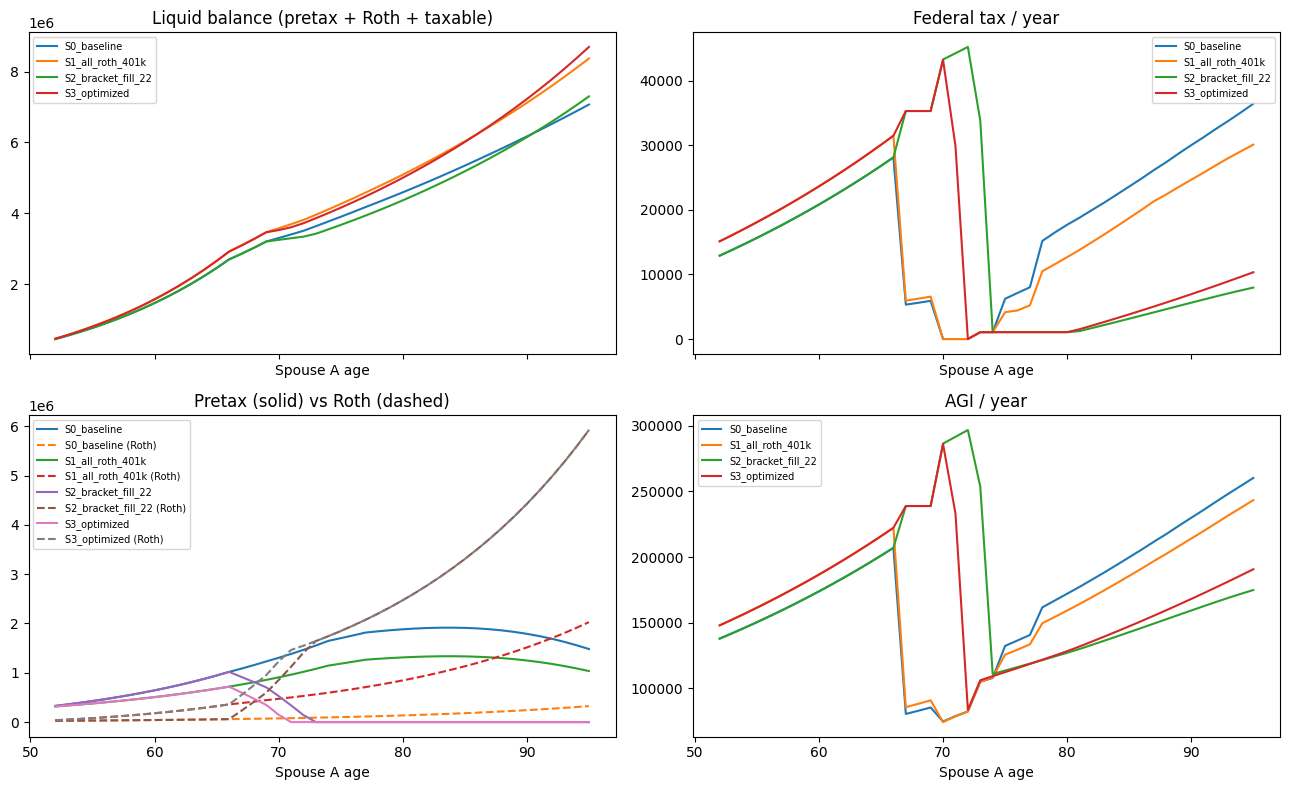

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for name, (_c, df, _s) in results.items():
    liquid = df['pretax_balance'] + df['roth_balance'] + df['taxable_balance']
    axes[0,0].plot(df['spouse_a_age'], liquid, label=name)
    axes[0,1].plot(df['spouse_a_age'], df['federal_tax'], label=name)
    axes[1,0].plot(df['spouse_a_age'], df['pretax_balance'], label=name, linestyle='-')
    axes[1,0].plot(df['spouse_a_age'], df['roth_balance'], label=f'{name} (Roth)', linestyle='--')
    axes[1,1].plot(df['spouse_a_age'], df['agi'], label=name)
axes[0,0].set_title('Liquid balance (pretax + Roth + taxable)')
axes[0,1].set_title('Federal tax / year')
axes[1,0].set_title('Pretax (solid) vs Roth (dashed)')
axes[1,1].set_title('AGI / year')
for ax in axes.flat:
    ax.legend(fontsize=7)
    ax.set_xlabel('Spouse A age')
plt.tight_layout()
plt.show()


## §5. Year-by-year detail of the winning strategy

Each row is one simulation year. Key columns:
- `wages` / `pension` / `ssn` — gross income items.
- `rmd_a` / `rmd_b` — required minimum distributions (per IRS Uniform Lifetime).
- `roth_conversion` — pretax → Roth conversion in gap years.
- `pretax_withdrawal` / `taxable_withdrawal` — strategy-driven retirement draws.
- `agi` / `federal_tax` — IRC §1 computation for the active filing status.
- `irmaa` / `irmaa_tier` — Medicare premium surcharge (Tier 0 = no surcharge).
- `marginal` — top federal ordinary bracket reached.
- `*_balance` columns — end-of-year liquid balances per bucket.
- `equity_return` / `bond_return` — that year's draws from the active `MarketModel`
  (constant for `DeterministicModel`, stochastic otherwise).


In [ ]:
winner_name = max(results, key=lambda n: results[n][2]['terminal_after_tax'])
winner_df = results[winner_name][1]
print(f'Winning strategy: {winner_name}')

show_cols = [
    'year','spouse_a_age','spouse_b_age','filing_status','wages','pension','ssn',
    'rmd_a','rmd_b','roth_conversion','pretax_withdrawal','taxable_withdrawal',
    'agi','federal_tax','irmaa','irmaa_tier','marginal',
    'pretax_a_balance','pretax_b_balance','roth_balance','taxable_balance',
]
fmt = {col: '${:>12,.0f}' for col in show_cols if col not in
       ('year','spouse_a_age','spouse_b_age','filing_status','irmaa_tier')}
fmt['marginal'] = '{:.0%}'
fmt['irmaa_tier'] = '{:>2.0f}'
winner_df[show_cols].iloc[15:].style.format(fmt)


Winning strategy: S3_optimized


,year,spouse_a_age,spouse_b_age,filing_status,wages,pension,ssn,rmd_a,rmd_b,roth_conversion,pretax_withdrawal,taxable_withdrawal,agi,federal_tax,irmaa,irmaa_tier,marginal,pretax_a_balance,pretax_b_balance,roth_balance,taxable_balance
15,2041,67,64,mfj,"$ 85,688",$ 0,$ 0,$ 0,$ 0,"$ 153,212",$ 0,$ 0,"$ 238,900","$ 35,302","$ 1,052",1,22%,"$ 294,859","$ 304,842","$ 548,584","$ 1,944,735"
16,2042,68,65,mfj,"$ 88,259",$ 0,$ 0,$ 0,$ 0,"$ 150,641",$ 0,$ 0,"$ 238,900","$ 35,302","$ 2,105",1,22%,"$ 152,871","$ 323,133","$ 746,792","$ 2,051,696"
17,2043,69,66,mfj,"$ 90,907",$ 0,$ 0,$ 0,$ 0,"$ 147,993",$ 0,$ 0,"$ 238,900","$ 35,302","$ 2,105",1,22%,"$ 5,170","$ 342,521","$ 954,254","$ 2,164,539"
18,2044,70,67,mfj,$ 0,$ 0,"$ 28,800",$ 0,$ 0,"$ 206,700",$ 0,"$ 118,798","$ 286,161","$ 43,225","$ 5,287",2,22%,"$ 2,222","$ 147,228","$ 1,230,611","$ 2,147,612"
19,2045,71,68,mfj,$ 0,$ 0,"$ 28,800",$ 0,$ 0,"$ 149,450",$ 0,"$ 120,799","$ 233,220","$ 29,902","$ 2,105",1,22%,$ 0,$ 0,"$ 1,462,865","$ 2,144,287"
20,2046,72,69,mfj,$ 0,$ 0,"$ 28,800",$ 0,$ 0,$ 0,$ 0,"$ 114,703","$ 83,674",$ 0,$ 0,0,10%,$ 0,$ 0,"$ 1,550,637","$ 2,171,595"
21,2047,73,70,mfj,$ 0,$ 0,"$ 50,400",$ 0,$ 0,$ 0,$ 0,"$ 118,635","$ 106,244","$ 1,064",$ 0,0,10%,$ 0,$ 0,"$ 1,643,675","$ 2,219,045"
22,2048,74,71,mfj,$ 0,$ 0,"$ 50,400",$ 0,$ 0,$ 0,$ 0,"$ 121,574","$ 109,290","$ 1,064",$ 0,0,10%,$ 0,$ 0,"$ 1,742,296","$ 2,266,004"
23,2049,75,72,mfj,$ 0,$ 0,"$ 50,400",$ 0,$ 0,$ 0,$ 0,"$ 124,587","$ 112,367","$ 1,064",$ 0,0,10%,$ 0,$ 0,"$ 1,846,833","$ 2,312,367"
24,2050,76,73,mfj,$ 0,$ 0,"$ 50,400",$ 0,$ 0,$ 0,$ 0,"$ 127,675","$ 115,479","$ 1,064",$ 0,0,10%,$ 0,$ 0,"$ 1,957,643","$ 2,358,022"


## §6. Tornado sensitivity

Base terminal NW: $6,846,307



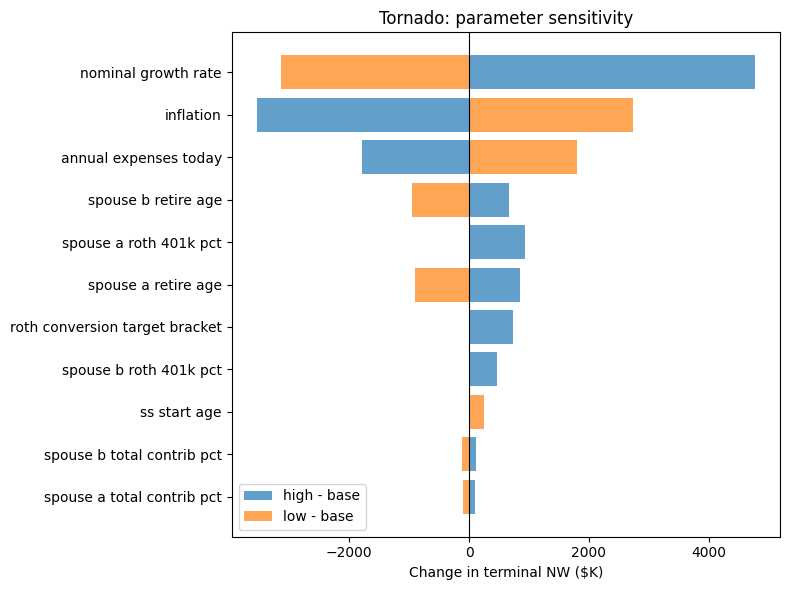

,param,low_value,high_value,delta_low,delta_high,swing
0,nominal_growth_rate,0.050,0.070,-3.134001e+06,4.772344e+06,4.772344e+06
1,inflation,0.015,0.035,2.735283e+06,-3.544951e+06,3.544951e+06
2,annual_expenses_today,63000.000,77000.000,1.793179e+06,-1.792641e+06,1.793179e+06
3,spouse_b_retire_age,65.000,69.000,-9.524224e+05,6.700966e+05,9.524224e+05
4,spouse_a_roth_401k_pct,0.000,1.000,0.000000e+00,9.307426e+05,9.307426e+05
5,spouse_a_retire_age,65.000,69.000,-9.025494e+05,8.429180e+05,9.025494e+05
6,roth_conversion_target_bracket,0.000,0.320,0.000000e+00,7.350977e+05,7.350977e+05
7,spouse_b_roth_401k_pct,0.000,1.000,0.000000e+00,4.620129e+05,4.620129e+05


In [ ]:
sens_df, base_terminal = tornado_sensitivity(cfg, inputs)
print(f'Base terminal NW: ${base_terminal:,.0f}\n')

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(sens_df))
ax.barh(y, sens_df['delta_high'].values / 1e3, alpha=0.7, label='high - base')
ax.barh(y, sens_df['delta_low'].values / 1e3, alpha=0.7, label='low - base')
ax.set_yticks(y); ax.set_yticklabels(sens_df['param'].str.replace('_', ' '))
ax.invert_yaxis(); ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Change in terminal NW ($K)')
ax.set_title('Tornado: parameter sensitivity'); ax.legend()
plt.tight_layout(); plt.show()
sens_df.head(8)


## §7. Recommended actions + takeaways

In [ ]:
print(render_takeaways(results, cfg))
print()
print(render_actions(results, sens_df, cfg, base_terminal))


### Run summary (44-year horizon, ages 52-95)
- Winning strategy: S3_optimized - terminal after-tax NW $8,796,837 (+$1,950,529 vs S0_baseline).
- IRMAA exposure (S3_optimized): 7 year(s), peak tier 2.
- Peak federal marginal rate (S3_optimized): 22%.

### Recommended actions

1. Hybrid plan (optimizer-chosen): set Spouse A Roth-401(k) split to 100% and Spouse B to 100%; target Roth conversions up to the 22% bracket in gap years.
   - Expected lift vs S0_baseline: $1,950,529 terminal after-tax NW.

2. Highest-leverage knobs (top 3 by tornado swing):
   - nominal_growth_rate - swing $4,772,344; pushing it higher adds ~$4,772,344. Market assumption (not an action).
   - inflation - swing $3,544,951; pushing it lower adds ~$2,735,283. Macro assumption only; useful as a stress-test.
   - annual_expenses_today - swing $1,793,179; pushing it lower adds ~$1,793,179. Trim annual spending toward $63,000.

3. Always-good hygiene:
   - Max out the HSA family contribution (triple-tax-advantaged).
 

## §8. Monte Carlo — sequence-of-returns risk

The deterministic simulator above assumes a flat 6%/yr return every year.
That hides "sequence-of-returns risk": a market crash early in retirement
hurts a withdrawing portfolio far more than the same crash late in life.

Below we re-run the same `cfg` with a `LognormalModel` (independent yearly
draws, μ=7%, σ=18% for equities) and a `BootstrapModel` (block-bootstrap
from 1928–2023 historical S&P + 10y-Treasury data). The summary reports:

- `prob_success` — fraction of paths whose liquid balance never falls
  below that year's spending need.
- `terminal_p5/p50/p95` — 5th / median / 95th percentile of terminal
  after-tax NW.
- `cvar_terminal_p10` — average terminal NW across the worst-10% paths
  (the metric a risk-averse retiree should actually optimize on).

Use `simulate_paths(..., n_paths=2000)` for tighter tails; the 200-path
demo below runs in a few seconds.


In [ ]:
cfg_lognormal = replace(cfg, market=LognormalModel(equity_mu=0.07, equity_sigma=0.18,
                                                  bond_mu=0.04, bond_sigma=0.06))
cfg_bootstrap = replace(cfg, market=BootstrapModel(block_size=5))

mc_lognormal = simulate_paths(cfg_lognormal, inputs, n_paths=200, seed=42)
mc_bootstrap = simulate_paths(cfg_bootstrap, inputs, n_paths=200, seed=42)

mc_summary = pd.DataFrame({
    'lognormal':  mc_lognormal.summary(),
    'bootstrap':  mc_bootstrap.summary(),
}).T
mc_summary


,n_paths,prob_success,terminal_p5,terminal_p50,terminal_p95,cvar_terminal_p10,cvar_terminal_p20,lifetime_tax_p50,lifetime_irmaa_p50,median_ruin_year_offset
lognormal,200.0,0.85,1.275863e+04,5.566199e+06,5.946002e+07,1.434576e+04,1.452324e+05,453336.953377,7157.851880,35.0
bootstrap,200.0,0.97,1.193316e+06,3.927672e+07,2.912463e+08,1.452861e+06,4.787756e+06,916736.408525,61503.397085,40.0


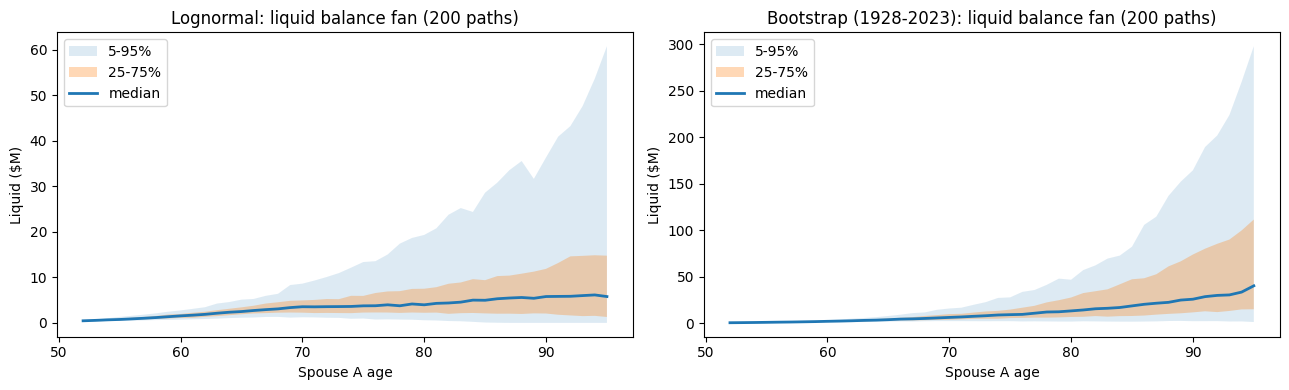

In [ ]:
# Fan chart of liquid balance across all 200 paths.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mc, title in [(axes[0], mc_lognormal, 'Lognormal'),
                      (axes[1], mc_bootstrap, 'Bootstrap (1928-2023)')]:
    ages = mc.paths[0]['spouse_a_age'].to_numpy()
    arr = np.stack([
        (df['pretax_balance'] + df['roth_balance'] + df['taxable_balance']).to_numpy()
        for df in mc.paths
    ]) / 1e6
    p5, p25, p50, p75, p95 = [np.percentile(arr, p, axis=0) for p in (5,25,50,75,95)]
    ax.fill_between(ages, p5, p95, alpha=0.15, label='5-95%')
    ax.fill_between(ages, p25, p75, alpha=0.30, label='25-75%')
    ax.plot(ages, p50, lw=2, label='median')
    ax.set_title(f'{title}: liquid balance fan ({mc.n_paths} paths)')
    ax.set_xlabel('Spouse A age'); ax.set_ylabel('Liquid ($M)'); ax.legend()
plt.tight_layout(); plt.show()


## §9. Widow's-penalty stress test

Realistic plans must stress the case where one spouse dies and the
survivor switches from MFJ to single-filer status. The single-filer
penalty:

- Brackets compress (the 22% bracket caps at ~$103k for single vs $207k MFJ).
- Standard deduction halves.
- IRMAA thresholds for Medicare premiums roughly halve.
- Survivor receives only the *larger* of the two SS checks, not both.
- Pension annuity scales by the joint-and-survivor election (default 50%).

Below we model Spouse A dying at year 25 (age 75) and re-run S3.


In [ ]:
cfg_widow = replace(s3_cfg, mortality=Mortality(year_of_death_a=25,
                                               pension_survivor_pct=0.5))

df_baseline = results['S3_optimized'][1]
df_widow = simulate(cfg_widow, inputs)

cmp = pd.DataFrame({
    'baseline (both alive)': summarize(df_baseline),
    'widow (A dies year 25)': summarize(df_widow),
}).T
cmp


,lifetime_tax_npv,lifetime_irmaa_npv,terminal_after_tax,peak_marginal,years_irmaa,peak_irmaa_tier,min_balance
baseline (both alive),438761.252320,9742.583506,8.796837e+06,0.22,7.0,2.0,463734.905
widow (A dies year 25),505510.084271,28354.931840,7.727601e+06,0.22,25.0,3.0,463734.905


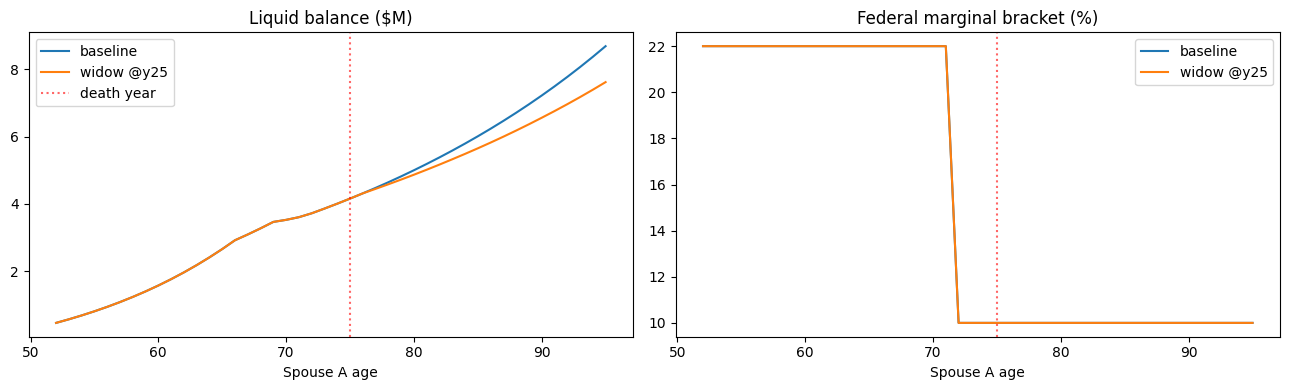

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
liq_b = df_baseline['pretax_balance'] + df_baseline['roth_balance'] + df_baseline['taxable_balance']
liq_w = df_widow['pretax_balance'] + df_widow['roth_balance'] + df_widow['taxable_balance']
axes[0].plot(df_baseline['spouse_a_age'], liq_b/1e6, label='baseline')
axes[0].plot(df_widow['spouse_a_age'], liq_w/1e6, label='widow @y25')
axes[0].axvline(75, color='red', ls=':', alpha=0.6, label='death year')
axes[0].set_title('Liquid balance ($M)'); axes[0].set_xlabel('Spouse A age'); axes[0].legend()
axes[1].plot(df_baseline['spouse_a_age'], df_baseline['marginal']*100, label='baseline')
axes[1].plot(df_widow['spouse_a_age'], df_widow['marginal']*100, label='widow @y25')
axes[1].axvline(75, color='red', ls=':', alpha=0.6)
axes[1].set_title('Federal marginal bracket (%)'); axes[1].set_xlabel('Spouse A age'); axes[1].legend()
plt.tight_layout(); plt.show()


## §10. Tax-regime change — TCJA sunset stress test

The current `TCJA_EXTENDED` regime assumes Congress extends TCJA past
its scheduled 2025 expiration. If TCJA actually expires, brackets revert
to roughly the pre-TCJA structure with widths inflation-adjusted forward
(~1.30× the 2017 nominals; standard deduction roughly halves).

We model this with `regime_change_year_offset` + `regime_change_target`,
swapping to `SUNSET_2026` at year 5 (i.e. starting in 2031).


In [ ]:
cfg_sunset = replace(s3_cfg, regime_change_year_offset=5,
                                    regime_change_target=SUNSET_2026)
df_sunset = simulate(cfg_sunset, inputs)

# Re-optimize S3 *under* the sunset assumption to see how the optimizer
# responds — typically conversions become more attractive in years before
# the regime change.
cfg_sunset_base = replace(cfg, regime_change_year_offset=5,
                                regime_change_target=SUNSET_2026)
s3_sunset_cfg, _ = optimize_s3(cfg_sunset_base, inputs, objective='terminal')
df_sunset_opt = simulate(s3_sunset_cfg, inputs)

cmp = pd.DataFrame({
    'baseline (TCJA forever)':       summarize(df_baseline),
    'sunset @y5 (S3 unchanged)':     summarize(df_sunset),
    'sunset @y5 (re-optimized S3)':  summarize(df_sunset_opt),
}).T
cmp


,lifetime_tax_npv,lifetime_irmaa_npv,terminal_after_tax,peak_marginal,years_irmaa,peak_irmaa_tier,min_balance
baseline (TCJA forever),438761.252320,9742.583506,8.796837e+06,0.22,7.0,2.0,463734.905
sunset @y5 (S3 unchanged),588142.586404,6158.016222,7.473495e+06,0.28,8.0,1.0,463734.905
sunset @y5 (re-optimized S3),588142.586404,6158.016222,7.473495e+06,0.28,8.0,1.0,463734.905


In [ ]:
print(f'Original S3 conv target:        {s3_cfg.roth_conversion_target_bracket:.0%}')
print(f'Re-optimized under sunset:      {s3_sunset_cfg.roth_conversion_target_bracket:.0%}')
print(f'Original S3 Roth-401(k) (A/B):  {s3_cfg.spouse_a_roth_401k_pct:.0%} / {s3_cfg.spouse_b_roth_401k_pct:.0%}')
print(f'Re-optimized Roth-401(k) (A/B): {s3_sunset_cfg.spouse_a_roth_401k_pct:.0%} / {s3_sunset_cfg.spouse_b_roth_401k_pct:.0%}')


Original S3 conv target:        22%
Re-optimized under sunset:      0%
Original S3 Roth-401(k) (A/B):  100% / 100%
Re-optimized Roth-401(k) (A/B): 100% / 100%


## §11. Smile-shaped retirement spending + lump events

Real spending follows the Blanchett "retirement smile":

- 100% of base in working years
- 115% of base in the "go-go" years (65–74; travel, hobbies)
- 95% of base in the "slow-go" years (75–84)
- 100% in the "no-go" years (85+) plus an LTC shock in the last 3
  years ($80k/yr today's dollars).

Plus we'll model a $50k wedding gift in year 15 and a $60k new car in year 22.


In [ ]:
smile = SpendingProfile.retirement_smile(
    base_spending=inputs.annual_expenses, inflation=0.025,
    ltc_years=3, ltc_annual_today=80_000.0,
)
smile.lump_events = [
    LumpEvent(year_offset=15, amount_today=50_000.0, label='kid wedding'),
    LumpEvent(year_offset=22, amount_today=60_000.0, label='replace car'),
]

cfg_smile = replace(s3_cfg, spending=smile)
df_smile = simulate(cfg_smile, inputs)

cmp = pd.DataFrame({
    'flat $85k (baseline S3)':            summarize(df_baseline),
    'smile + LTC + 2 lump events':        summarize(df_smile),
}).T
cmp


,lifetime_tax_npv,lifetime_irmaa_npv,terminal_after_tax,peak_marginal,years_irmaa,peak_irmaa_tier,min_balance
flat $85k (baseline S3),438761.252320,9742.583506,8.796837e+06,0.22,7.0,2.0,463734.905
smile + LTC + 2 lump events,472248.263874,18728.473047,7.266320e+06,0.22,10.0,3.0,463734.905


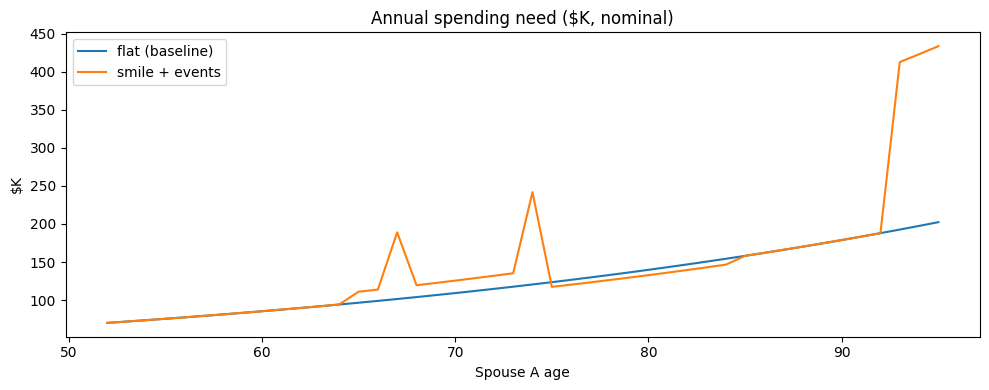

In [ ]:
# Show the actual spending need year-by-year so the smile shape is visible.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_baseline['spouse_a_age'], df_baseline['spending_need']/1e3, label='flat (baseline)')
ax.plot(df_smile['spouse_a_age'],    df_smile['spending_need']/1e3,    label='smile + events')
ax.set_title('Annual spending need ($K, nominal)')
ax.set_xlabel('Spouse A age'); ax.set_ylabel('$K'); ax.legend()
plt.tight_layout(); plt.show()


## §12. Asset location — bonds in pretax, equities in Roth

By default the package's `AssetLocation()` puts:

- 40% equity / 60% bond in the **pretax** sleeve  — bonds get sheltered
  from the ordinary-income tax line they would otherwise feed.
- 100% equity in the **Roth** sleeve              — maximize tax-free compounding.
- 80% equity / 20% bond in the **taxable** sleeve.
- 80% equity / 20% bond in the **HSA** sleeve.

Pair that with a `LognormalModel` so equity and bond returns differ
year-to-year, and the asset-location effect becomes visible.


In [ ]:
cfg_asset_uniform = replace(s3_cfg, market=LognormalModel(),
                                  asset_location=AssetLocation.uniform(equity_pct=0.6))
cfg_asset_located = replace(s3_cfg, market=LognormalModel(),
                                  asset_location=AssetLocation())   # bonds-in-pretax default

mc_uniform = simulate_paths(cfg_asset_uniform, inputs, n_paths=200, seed=7)
mc_located = simulate_paths(cfg_asset_located, inputs, n_paths=200, seed=7)

cmp = pd.DataFrame({
    'uniform 60/40 everywhere':           mc_uniform.summary(),
    'asset-located (bonds in pretax)':    mc_located.summary(),
}).T
cmp


,n_paths,prob_success,terminal_p5,terminal_p50,terminal_p95,cvar_terminal_p10,cvar_terminal_p20,lifetime_tax_p50,lifetime_irmaa_p50,median_ruin_year_offset
uniform 60/40 everywhere,200.0,0.980,706217.343214,5.296456e+06,2.408266e+07,639844.519845,1.335235e+06,412071.603113,8425.972768,37.0
asset-located (bonds in pretax),200.0,0.915,30504.895740,5.700138e+06,4.219256e+07,100130.770840,6.853085e+05,410669.559050,7042.708612,39.0


## Recap — what changed in v2

| Capability | Where to set it | Effect on output |
|---|---|---|
| Stochastic returns | `cfg.market = LognormalModel(...)` | adds `prob_success`, percentile / CVaR metrics |
| Mortality / widow's penalty | `cfg.mortality = Mortality(year_of_death_a=...)` | flips filing status to single after death; SS / pension scale per election |
| Asset location | `cfg.asset_location = AssetLocation(...)` | per-account equity/bond split — bonds in pretax, equities in Roth |
| Smile spending + lumps | `cfg.spending = SpendingProfile.retirement_smile(...)` | per-age multipliers + lump events + LTC shock |
| Tax regime swap | `cfg.tax_regime`, `cfg.regime_change_year_offset` + `regime_change_target` | per-year regime selection |
| Optimizer objective | `optimize_s3(cfg, inputs, objective='cvar')` | CVaR or `'p_success'` instead of point-estimate terminal NW |

The `tax_optimizer/` package is the single source of truth — every cell
in this notebook imports from it. Run `python -m tax_optimizer --help`
for the equivalent CLI invocation.
